# 📚 Clase No. 4: Consultas SQL con PySpark — Agregaciones, Joins y más


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, avg, count, when, coalesce, lit

# Crear una SparkSession si no existe
spark = SparkSession.builder.appName("DataFrameKaggle").getOrCreate()

# Crear un DataFrame a partir de un archivo CSV local
# Se asume que el archivo 'libros.csv' es el que se quiere usar basado en el notebook existente.
# Si tienes un CSV diferente de Kaggle que sea directamente descargable, por favor, proporciona su URL.
df = spark.read.csv("/content/CHD_preprocessed.csv", header=True, inferSchema=True)

# Mostrar el DataFrame
df.show()

+----+---+---------+-------------+----------+------+---------------+------------+--------+-------+-----+-----+-----+---------+-------+----------+
|male|age|education|currentSmoker|cigsPerDay|BPMeds|prevalentStroke|prevalentHyp|diabetes|totChol|sysBP|diaBP|  BMI|heartRate|glucose|TenYearCHD|
+----+---+---------+-------------+----------+------+---------------+------------+--------+-------+-----+-----+-----+---------+-------+----------+
|   1| 39|        1|            0|       0.0|   0.0|              0|           0|       0|  195.0|106.0| 70.0|26.97|     80.0|   77.0|         0|
|   0| 46|        0|            0|       0.0|   0.0|              0|           0|       0|  250.0|121.0| 81.0|28.73|     95.0|   76.0|         0|
|   1| 48|        0|            1|      20.0|   0.0|              0|           0|       0|  245.0|127.5| 80.0|25.34|     75.0|   70.0|         0|
|   0| 61|        1|            1|      30.0|   0.0|              0|           1|       0|  225.0|150.0| 95.0|28.58|     65.

In [5]:
cols = df.columns
df.select(cols[:10]).show()

+----+---+---------+-------------+----------+------+---------------+------------+--------+-------+
|male|age|education|currentSmoker|cigsPerDay|BPMeds|prevalentStroke|prevalentHyp|diabetes|totChol|
+----+---+---------+-------------+----------+------+---------------+------------+--------+-------+
|   1| 39|        1|            0|       0.0|   0.0|              0|           0|       0|  195.0|
|   0| 46|        0|            0|       0.0|   0.0|              0|           0|       0|  250.0|
|   1| 48|        0|            1|      20.0|   0.0|              0|           0|       0|  245.0|
|   0| 61|        1|            1|      30.0|   0.0|              0|           1|       0|  225.0|
|   0| 46|        1|            1|      23.0|   0.0|              0|           0|       0|  285.0|
|   0| 43|        0|            0|       0.0|   0.0|              0|           1|       0|  228.0|
|   0| 63|        0|            0|       0.0|   0.0|              0|           0|       0|  205.0|
|   0| 45|

In [6]:
# Contar el número de filas donde la columna 'male' es 1
conteo_hombres = df.filter(col("male") == 1).count()

print(f"Número de hombres en el DataFrame: {conteo_hombres}")

Número de hombres en el DataFrame: 1766


In [ ]:
# Contar el número de filas donde la columna 'male' es 0 (asumiendo que 0 representa 'no-male' o femenino)
conteo_mujeres = df.filter(col("male") == 0).count()

print(f"Número de mujeres en el DataFrame: {conteo_mujeres}")

In [7]:
# Contar el número total de filas en el DataFrame para verificar la suma de hombres y mujeres
conteo_total_filas = df.count()

print(f"Número total de filas en el DataFrame: {conteo_total_filas}")

Número total de filas en el DataFrame: 4133


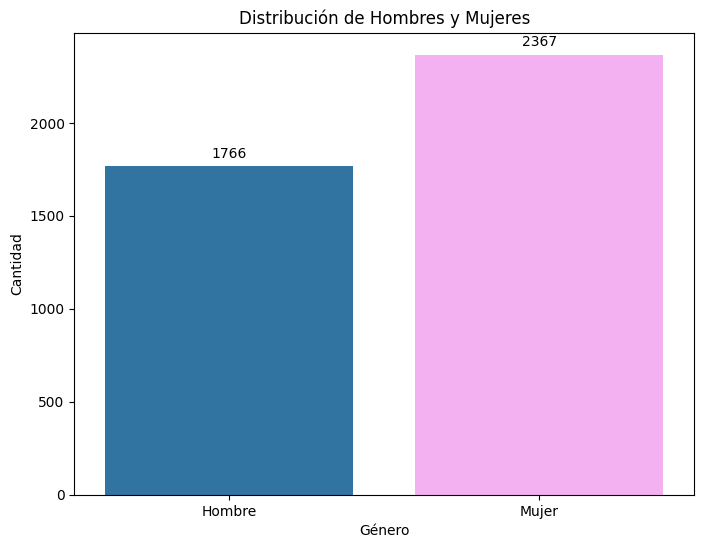

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la ocurrencia de 0s y 1s en la columna 'male'
gender_counts = df.groupBy("male").count()

# Convertir a Pandas DataFrame para visualización
gender_counts_pd = gender_counts.toPandas()

# Mapear los valores numéricos a etiquetas para la gráfica
gender_counts_pd['gender_label'] = gender_counts_pd['male'].replace({1: 'Hombre', 0: 'Mujer'})

# Crear la gráfica de barras
plt.figure(figsize=(8, 6))
# Cambiamos la paleta de colores aquí. Puedes probar otras como 'pastel', 'dark', 'bright', 'deep', 'muted', 'colorblind', o una lista de colores personalizada.
# Se ha actualizado la llamada a sns.barplot para incluir `hue='gender_label'` y `legend=False` para evitar un FutureWarning.
ax = sns.barplot(x='gender_label', y='count', data=gender_counts_pd, hue='gender_label', palette=['#1f77b4', '#FFA6FB'], legend=False) # Ejemplo con colores personalizados azul y naranja

# Añadir las etiquetas de valor encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribución de Hombres y Mujeres')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

In [15]:
from google.colab import files
import os

# Sube el archivo 'libros.csv'
uploaded = files.upload()

# Mueve el archivo subido a la ubicación esperada si no está ya allí
for fn in uploaded.keys():
  print(f'El archivo "{fn}" ha sido subido.')
  # Verifica si el archivo subido es 'libros.csv' y lo mueve a /content si es necesario
  if fn == 'libros.csv' and not os.path.exists('/content/libros.csv'):
    os.rename(fn, '/content/libros.csv')
  elif fn != 'libros.csv':
    print(f"Advertencia: Se esperaba 'libros.csv' pero se subió '{fn}'. Asegúrate de que el nombre del archivo sea correcto.")


Saving libros (1).csv to libros (1).csv
El archivo "libros (1).csv" ha sido subido.
Advertencia: Se esperaba 'libros.csv' pero se subió 'libros (1).csv'. Asegúrate de que el nombre del archivo sea correcto.


In [17]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, avg, count, when, coalesce, lit

spark = SparkSession.builder.appName("CSVtoDataFrame").getOrCreate()

df = spark.read.csv("/content/libros (1).csv", header=True, inferSchema=True)
df.show()

+--------------------+--------------------+-----------+-------+-----+----+-----------+
|                Name|              Author|User Rating|Reviews|Price|Year|      Genre|
+--------------------+--------------------+-----------+-------+-----+----+-----------+
|10-Day Green Smoo...|            JJ Smith|        4.7|  17350|    8|2016|Non Fiction|
|   11/22/63: A Novel|        Stephen King|        4.6|   2052|   22|2011|    Fiction|
|12 Rules for Life...|  Jordan B. Peterson|        4.7|  18979|   15|2018|Non Fiction|
|1984 (Signet Clas...|       George Orwell|        4.7|  21424|    6|2017|    Fiction|
|5,000 Awesome Fac...|National Geograph...|        4.8|   7665|   12|2019|Non Fiction|
|A Dance with Drag...| George R. R. Martin|        4.4|  12643|   11|2011|    Fiction|
|A Game of Thrones...| George R. R. Martin|        4.7|  19735|   30|2014|    Fiction|
|A Gentleman in Mo...|         Amor Towles|        4.7|  19699|   15|2017|    Fiction|
|A Higher Loyalty:...|         James Comey|

In [30]:
df.select(count("Author")).show()

+-------------+
|count(Author)|
+-------------+
|          550|
+-------------+



In [23]:
df.groupby("Year").agg(count("*").alias("total_libros")).show(5)

+----+------------+
|Year|total_libros|
+----+------------+
|2018|          50|
|2015|          50|
|2013|          50|
|2014|          50|
|2019|          50|
+----+------------+
only showing top 5 rows


# Agregaciones (groupBy().agg())

In [31]:
df.groupBy("Author").agg(count("*").alias("total_libros")).show(5)

+--------------+------------+
|        Author|total_libros|
+--------------+------------+
|   Sarah Young|           6|
|    Jill Twiss|           1|
|    Sara Gruen|           1|
|    Doug Lemov|           2|
|Justin Halpern|           1|
+--------------+------------+
only showing top 5 rows


# sum() y avg()

In [38]:
df.agg(
    avg("User Rating").alias("rating_promedio"),
    sum("Reviews").alias("reviews_totales")
).show(5)

+-----------------+---------------+
|  rating_promedio|reviews_totales|
+-----------------+---------------+
|4.618363636363641|        6574305|
+-----------------+---------------+



# Agrupaciones

In [39]:
df.groupBy("Genre", "Year").agg(
    avg("Price").alias("precio_promedio"),
    sum("Reviews").alias("total_reviews")
).orderBy("Year").show(10)

+-----------+----+------------------+-------------+
|      Genre|Year|   precio_promedio|total_reviews|
+-----------+----+------------------+-------------+
|    Fiction|2009|15.583333333333334|       156824|
|Non Fiction|2009| 15.23076923076923|        78682|
|Non Fiction|2010|              16.0|       105796|
|    Fiction|2010|               9.7|       168185|
|    Fiction|2011|11.619047619047619|       217041|
|Non Fiction|2011|17.620689655172413|       188000|
|    Fiction|2012|12.285714285714286|       417821|
|Non Fiction|2012|17.482758620689655|       236725|
|Non Fiction|2013|18.192307692307693|       175223|
|    Fiction|2013|10.708333333333334|       479684|
+-----------+----+------------------+-------------+
only showing top 10 rows


# Joins

In [50]:
# Crear un DataFrame adicional
data_paises = [("JJ Smith", "EE.UU."), ("Stephen King", "Reino Unido"), ("George Orwell", "Canadá")]
df_paises = spark.createDataFrame(data_paises, ["Author", "Pais"])

# Realizamos un join entre ambos
df_join = df.join(df_paises, on="Author", how="left")
df_join.select("Author", "Pais", "Name").show(20)

+--------------------+-----------+--------------------+
|              Author|       Pais|                Name|
+--------------------+-----------+--------------------+
|            JJ Smith|     EE.UU.|10-Day Green Smoo...|
|       Jaycee Dugard|       NULL|A Stolen Life: A ...|
|        Stephen King|Reino Unido|   11/22/63: A Novel|
|Adult Coloring Bo...|       NULL|Adult Coloring Bo...|
|       George Orwell|     Canadá|1984 (Signet Clas...|
|National Geograph...|       NULL|5,000 Awesome Fac...|
|Coloring Books fo...|       NULL|Adult Coloring Bo...|
|   Madeleine L'Engle|       NULL|A Wrinkle in Time...|
|         Amor Towles|       NULL|A Gentleman in Mo...|
|    Larry Schweikart|       NULL|A Patriot's Histo...|
|        Steve Harvey|       NULL|Act Like a Lady, ...|
|     Fredrik Backman|       NULL|A Man Called Ove:...|
|     Fredrik Backman|       NULL|A Man Called Ove:...|
|       Anthony Doerr|       NULL|All the Light We ...|
|  Jordan B. Peterson|       NULL|12 Rules for L

# when: condicionales

In [ ]:
df.withColumn("categoria_precio", when(col("Price") < 10, "Barato")
                                     .when(col("Price") < 20, "Medio")
                                     .otherwise("Caro")).select("Name", "Price", "categoria_precio").show(5)

+--------------------+-----+----------------+
|                Name|Price|categoria_precio|
+--------------------+-----+----------------+
|10-Day Green Smoo...|    8|          Barato|
|   11/22/63: A Novel|   22|            Caro|
|12 Rules for Life...|   15|           Medio|
|1984 (Signet Clas...|    6|          Barato|
|5,000 Awesome Fac...|   12|           Medio|
+--------------------+-----+----------------+
only showing top 5 rows



# coalesce: reemplaza un nulo

In [ ]:
df.withColumn("Reviews_sin_nulos", coalesce(col("Reviews"), lit(0))).select("Name", "Reviews", "Reviews_sin_nulos").show(5)

+--------------------+-------+-----------------+
|                Name|Reviews|Reviews_sin_nulos|
+--------------------+-------+-----------------+
|10-Day Green Smoo...|  17350|            17350|
|   11/22/63: A Novel|   2052|             2052|
|12 Rules for Life...|  18979|            18979|
|1984 (Signet Clas...|  21424|            21424|
|5,000 Awesome Fac...|   7665|             7665|
+--------------------+-------+-----------------+
only showing top 5 rows



# lit : agrega una columna constante

In [ ]:
df.withColumn("Formato", lit("Físico")).select("Name", "Formato").show(5)

+--------------------+-------+
|                Name|Formato|
+--------------------+-------+
|10-Day Green Smoo...| Físico|
|   11/22/63: A Novel| Físico|
|12 Rules for Life...| Físico|
|1984 (Signet Clas...| Físico|
|5,000 Awesome Fac...| Físico|
+--------------------+-------+
only showing top 5 rows

